Figures folder created at: figures
SOM training completed


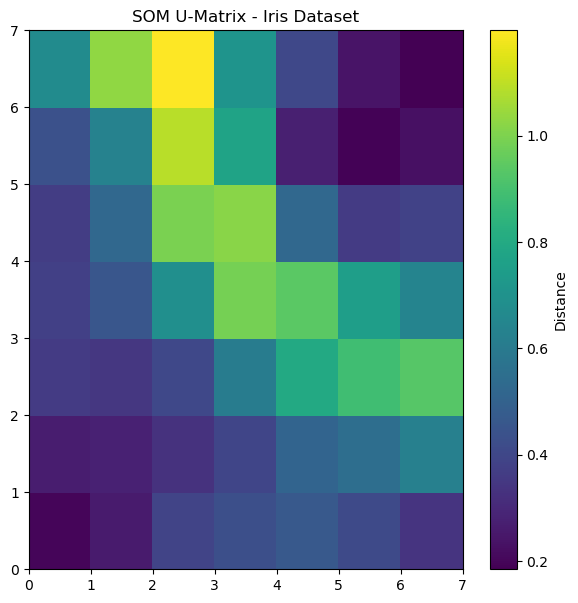

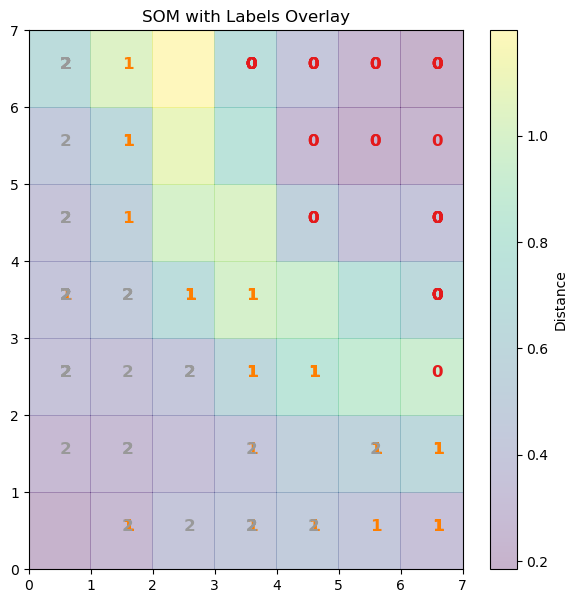

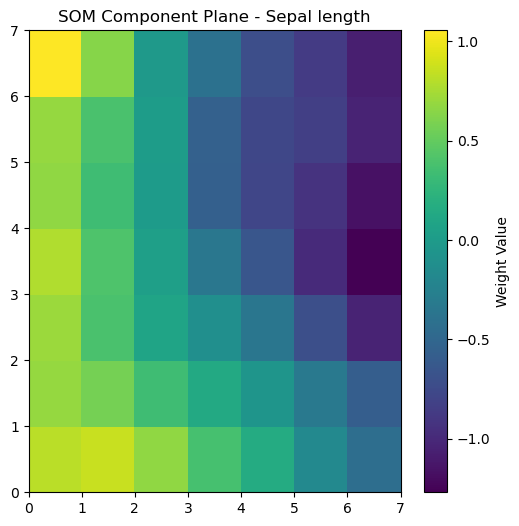

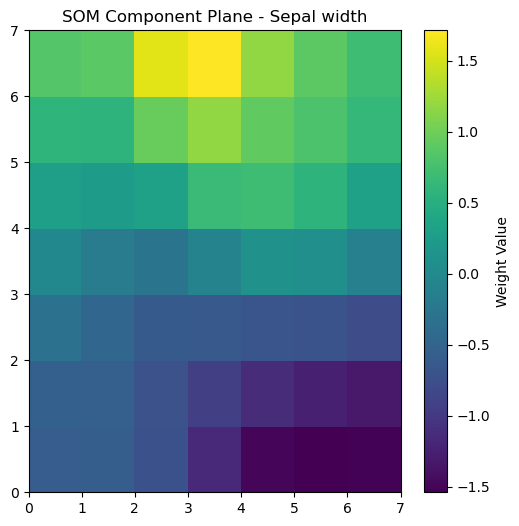

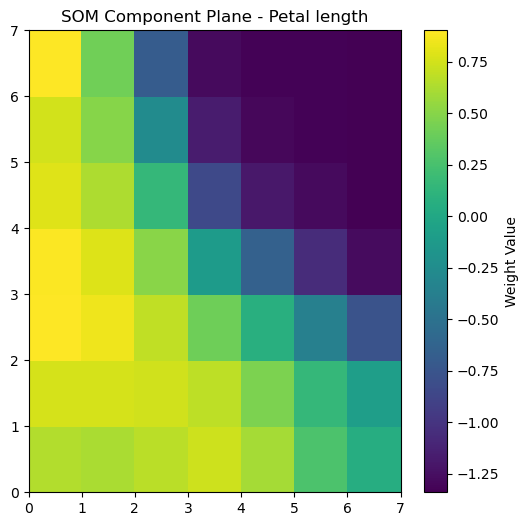

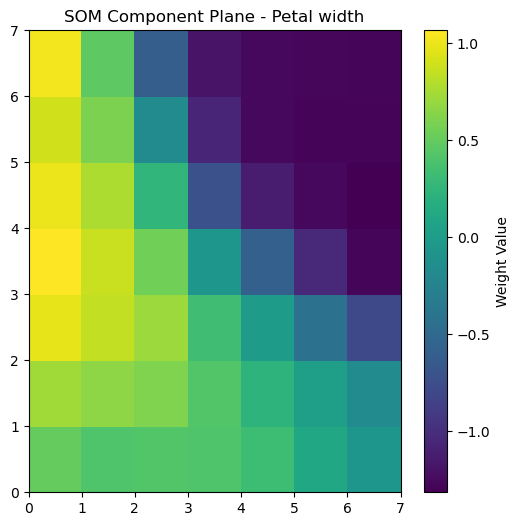

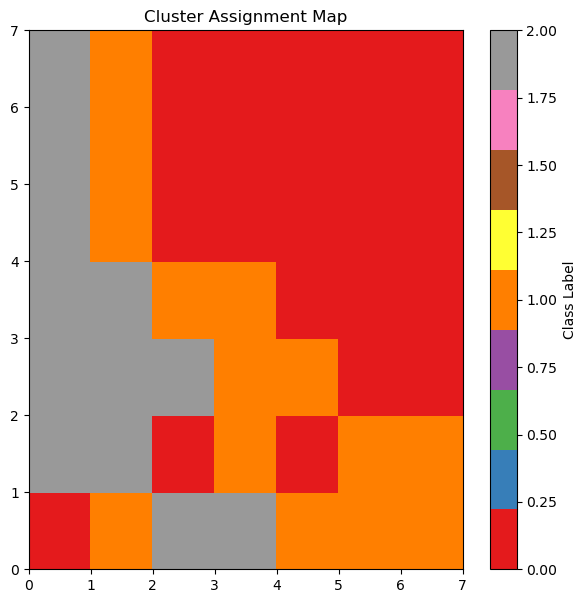

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from collections import Counter

# -------------------------------
# Create figures folder
# -------------------------------
figures_path = "figures"
if not os.path.exists(figures_path):
    os.makedirs(figures_path)
print("Figures folder created at:", figures_path)

# -------------------------------
# Load and scale dataset
# -------------------------------
data = load_iris()
X = StandardScaler().fit_transform(data.data)
y = data.target
features = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']

# -------------------------------
# SOM parameters
# -------------------------------
grid_size = 7
input_len = X.shape[1]
iterations = 1000
learning_rate = 0.5
sigma = 1.0

# -------------------------------
# Initialize weights randomly
# -------------------------------
weights = np.random.rand(grid_size, grid_size, input_len)

# -------------------------------
# Gaussian neighborhood function
# -------------------------------
def neighborhood(dist_sq, sigma):
    return np.exp(-dist_sq / (2 * sigma**2))

# -------------------------------
# Train SOM
# -------------------------------
for it in range(iterations):
    sample = X[np.random.randint(0, X.shape[0])]
    # Find Best Matching Unit (BMU)
    diff = weights - sample
    dist_sq = np.sum(diff**2, axis=2)
    bmu_idx = np.unravel_index(np.argmin(dist_sq), (grid_size, grid_size))
    
    # Update weights
    for i in range(grid_size):
        for j in range(grid_size):
            dist_to_bmu_sq = (i - bmu_idx[0])**2 + (j - bmu_idx[1])**2
            h = neighborhood(dist_to_bmu_sq, sigma)
            weights[i,j,:] += learning_rate * h * (sample - weights[i,j,:])

print("SOM training completed")

# -------------------------------
# 1. U-Matrix
# -------------------------------
u_matrix = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        neighbors = []
        if i > 0: neighbors.append(weights[i-1,j,:])
        if i < grid_size-1: neighbors.append(weights[i+1,j,:])
        if j > 0: neighbors.append(weights[i,j-1,:])
        if j < grid_size-1: neighbors.append(weights[i,j+1,:])
        u_matrix[i,j] = np.mean([np.linalg.norm(weights[i,j,:]-n) for n in neighbors])

plt.figure(figsize=(7,7))
plt.pcolor(u_matrix.T, cmap='viridis')
plt.colorbar(label='Distance')
plt.title("SOM U-Matrix - Iris Dataset")
plt.savefig(f"{figures_path}/som_u_matrix.png")
plt.show()

# -------------------------------
# 2. Label Overlay
# -------------------------------
plt.figure(figsize=(7,7))
for i, x in enumerate(X):
    diff = weights - x
    dist_sq = np.sum(diff**2, axis=2)
    w = np.unravel_index(np.argmin(dist_sq), (grid_size, grid_size))
    plt.text(w[0]+0.5, w[1]+0.5, str(y[i]), color=plt.cm.Set1(y[i]/2.),
             fontdict={'weight':'bold','size':12})
plt.pcolor(u_matrix.T, cmap='viridis', alpha=0.3)
plt.colorbar(label='Distance')
plt.title("SOM with Labels Overlay")
plt.savefig(f"{figures_path}/som_labels_overlay.png")
plt.show()

# -------------------------------
# 3. Component Planes
# -------------------------------
for f in range(input_len):
    plt.figure(figsize=(6,6))
    plt.pcolor(weights[:,:,f].T, cmap='viridis')
    plt.colorbar(label='Weight Value')
    plt.title(f"SOM Component Plane - {features[f]}")
    plt.savefig(f"{figures_path}/component_plane_{f}.png")
    plt.show()

# -------------------------------
# 4. Cluster Assignment Map
# -------------------------------
label_map = {}
for i, x in enumerate(X):
    diff = weights - x
    dist_sq = np.sum(diff**2, axis=2)
    w = np.unravel_index(np.argmin(dist_sq), (grid_size, grid_size))
    
    if w not in label_map:
        label_map[w] = []
    label_map[w].append(y[i])

cluster_map = np.zeros((grid_size, grid_size))
for position, labels in label_map.items():
    cluster_map[position] = Counter(labels).most_common(1)[0][0]

plt.figure(figsize=(7,7))
plt.pcolor(cluster_map.T, cmap='Set1')
plt.colorbar(label='Class Label')
plt.title("Cluster Assignment Map")
plt.savefig(f"{figures_path}/cluster_map.png")
plt.show()